# EFD Database Exploration

Notebook for exploring the Rubin Observatory Engineering and Facility Database (EFD).
Uses `lsst_efd_client` to browse topics and fetch time series data.

API reference: https://efd-client.lsst.io/api/lsst_efd_client.EfdClient.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

## Connect to the EFD

Common aliases: `usdf_efd`, `summit_efd`, `base_efd`, `tucson_teststand_efd`

In [2]:
client = EfdClient("usdf_efd")
print("Connected to EFD")

Connected to EFD


## Browse Available Topics

In [3]:
all_topics = await client.get_topics()
print(f"Total topics available: {len(all_topics)}")
all_topics[:20]

Total topics available: 3204


['lsst.sal.ATAOS.ackcmd',
 'lsst.sal.ATAOS.command_applyAxisOffset',
 'lsst.sal.ATAOS.command_applyFocusOffset',
 'lsst.sal.ATAOS.command_disable',
 'lsst.sal.ATAOS.command_disableCorrection',
 'lsst.sal.ATAOS.command_enable',
 'lsst.sal.ATAOS.command_enableCorrection',
 'lsst.sal.ATAOS.command_enterControl',
 'lsst.sal.ATAOS.command_exitControl',
 'lsst.sal.ATAOS.command_offset',
 'lsst.sal.ATAOS.command_resetOffset',
 'lsst.sal.ATAOS.command_setCorrectionModelOffsets',
 'lsst.sal.ATAOS.command_setLogLevel',
 'lsst.sal.ATAOS.command_setWavelength',
 'lsst.sal.ATAOS.command_standby',
 'lsst.sal.ATAOS.command_start',
 'lsst.sal.ATAOS.logevent_appliedSettingsMatchStart',
 'lsst.sal.ATAOS.logevent_atspectrographCorrectionCompleted',
 'lsst.sal.ATAOS.logevent_atspectrographCorrectionStarted',
 'lsst.sal.ATAOS.logevent_authList']

In [10]:
# Filter topics by keyword — edit to explore different subsystems
keyword = "ESS.airFlow"

matching = [t for t in all_topics if keyword.lower() in t.lower()]
print(f"Topics matching '{keyword}': {len(matching)}")
for t in matching:
    print(t)

Topics matching 'ESS.airFlow': 1
lsst.sal.ESS.airFlow


In [11]:
# Inspect fields for a topic of interest
topic = matching[0]  # or set explicitly, e.g. topic = "lsst.sal.MTMount.azimuth"
fields = await client.get_fields(topic)
print(f"Fields in '{topic}':")
for f in fields:
    print(f"  {f}")

Fields in 'lsst.sal.ESS.airFlow':
  direction
  direction
  directionStdDev
  directionStdDev
  location
  maxSpeed
  private_efdStamp
  private_identity
  private_kafkaStamp
  private_origin
  private_rcvStamp
  private_revCode
  private_seqNum
  private_sndStamp
  salIndex
  sensorName
  speed
  speedStdDev
  timestamp


In [12]:
# Get the full schema (field descriptions, units, etc.)
schema = await client.get_schema(topic)
schema

,name,description,units,aunits,is_array
0,salIndex,SAL index (only present for indexed SAL compon...,unitless,,False
1,private_sndStamp,Time of instance publication,second,s,False
2,private_rcvStamp,Time of instance reception,second,s,False
3,private_efdStamp,UTC time for EFD timestamp. An integer (the nu...,second,s,False
4,private_kafkaStamp,TAI time at which the Kafka message was created.,second,s,False
5,private_seqNum,Sequence number,unitless,,False
6,private_revCode,Revision hashcode,unitless,,False
7,private_identity,Identity of publisher: SAL component name for ...,unitless,,False
8,private_origin,Process ID of publisher,unitless,,False
9,sensorName,The name of the sensor.,unitless,,False


## Fetch and Plot Time Series

Times must be `astropy.time.Time` objects. The EFD index is UTC; TAI offsets
are handled internally by the client.

In [13]:
# Define time range in UTC
t_end   = Time("2026-01-15T05:00:00", scale="utc")
t_start = t_end - TimeDelta(1*u.hour)

print(f"Start : {t_start.iso}")
print(f"End   : {t_end.iso}")

Start : 2026-01-15 04:00:00.000
End   : 2026-01-15 05:00:00.000


In [14]:
# Fetch time series — use "*" for all fields or pass a list of field names
df = await client.select_time_series(
    topic,
    fields="speed",
    start=t_start,
    end=t_end,
    # index=None,  # set to an int for indexed SAL components (salIndex)
)

print(f"Rows: {len(df)}   Columns: {list(df.columns)}")
df.head()

Rows: 2993   Columns: ['speed']


,speed
2026-01-15 04:00:00.725902+00:00,6.4218
2026-01-15 04:00:02.006025+00:00,6.2550
2026-01-15 04:00:03.286389+00:00,6.4218
2026-01-15 04:00:04.566285+00:00,6.4218
2026-01-15 04:00:05.846379+00:00,6.4218


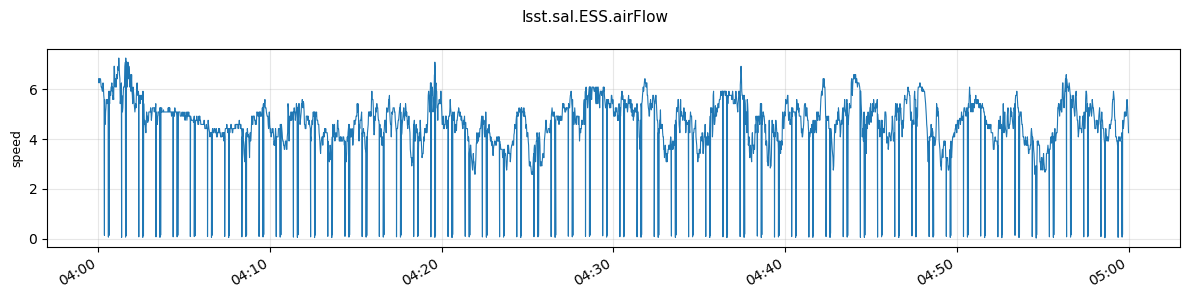

In [15]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(len(numeric_cols), 1,
                         figsize=(12, 3 * len(numeric_cols)),
                         sharex=True)
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    ax.plot(df.index, df[col], lw=0.8)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle(topic, fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Fetch Most Recent N Samples

`select_top_n` returns the last N records. Useful for a quick sanity check
on what a topic is currently publishing. Note: row order is not guaranteed.

In [17]:
df_recent = await client.select_top_n(topic, fields="speed", num=10)
df_recent.sort_index()

,speed
2026-03-24 20:36:12.189850+00:00,2.2518
2026-03-24 20:36:13.469667+00:00,1.9182
2026-03-24 20:36:14.749572+00:00,1.6680
2026-03-24 20:36:16.029603+00:00,1.4178
2026-03-24 20:36:17.309478+00:00,1.5846
2026-03-24 20:36:18.589797+00:00,1.2510
2026-03-24 20:36:19.869888+00:00,1.2510
2026-03-24 20:36:21.149632+00:00,1.5846
2026-03-24 20:36:22.429352+00:00,1.4178
2026-03-24 20:36:23.709008+00:00,1.3344


## Packed Time Series

High-rate topics (e.g. accelerometers, force actuators) store vector samples
per message. Use `select_packed_time_series` to unpack them into a flat
DataFrame with a proper timestamp index.

In [ ]:
# Example — edit topic and base_fields for your use case
# packed_topic = "lsst.sal.MTM1M3.forceActuatorData"
# base_field   = "primaryCylinderForce"  # expanded to primaryCylinderForce0, ...N
#
# df_packed = await client.select_packed_time_series(
#     packed_topic,
#     base_fields=base_field,
#     start=t_start,
#     end=t_end,
#     ref_timestamp_col="cRIO_timestamp",   # default
#     ref_timestamp_fmt="unix_tai",          # default
#     ref_timestamp_scale="tai",             # default
# )
# df_packed.head()

print("Uncomment and edit the block above for packed time series topics.")

## Basic Statistics and Resampling

In [18]:
df[numeric_cols].describe()

,speed
count,2993.000000
mean,4.458952
std,1.345514
min,0.020000
25%,4.086600
50%,4.753800
75%,5.254200
max,7.255800


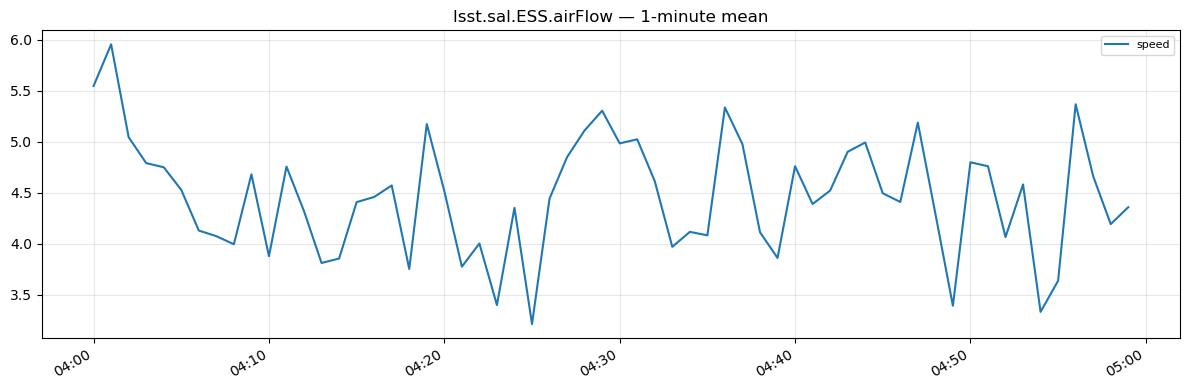

In [19]:
# Resample to a lower cadence
df_1min = df[numeric_cols].resample("1min").mean()

fig, ax = plt.subplots(figsize=(12, 4))
for col in numeric_cols:
    ax.plot(df_1min.index, df_1min[col], label=col)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_title(f"{topic} — 1-minute mean")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Raw InfluxQL Query

Use `influxql_query` when you need full control over the query
(aggregation functions, GROUP BY, WHERE clauses, etc.).

In [ ]:
# Build and preview a query string
query_str = client.build_time_range_query(
    topic,
    fields="*",
    start=t_start,
    end=t_end,
)
print(query_str)

In [ ]:
# Run a custom InfluxQL query
# custom_query = f'SELECT mean("actualPosition") FROM "{topic}" WHERE time > now() - 1h GROUP BY time(1m)'
# df_custom = await client.influxql_query(custom_query)
# df_custom.head()

print("Uncomment and edit the query above to run a custom InfluxQL query.")